# Sudoku

Sudoku is a logic-based, combinatorial number-placement puzzle. In classic Sudoku, the objective is to fill a 9 × 9 grid with digits so that each column, each row, and each of the nine 3 × 3 subgrids that compose the grid (also called "boxes", "blocks", or "regions") contains all of the digits from 1 to 9. The puzzle setter provides a partially completed grid, which, for a well-posed puzzle, has a single solution.

Definition: [Wikipedia](https://en-wikipedia-org.translate.goog/wiki/Sudoku?_x_tr_sl=en&_x_tr_tl=pt-BR&_x_tr_hl=pt-BR&_x_tr_pto=sc)

## Rules to be followed

* The values in the squares in any row must be each of 1 to 9
* The values in the squares in any column must be each of 1 to 9
* The values in the squares in any box must be each of 1 to 9
* There must be only one number within any square
* The starting sudoku numbers must be in those same places in the final solution

## Import libs

In [63]:
import pyomo.environ as pyo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import time

## Creating the Grid

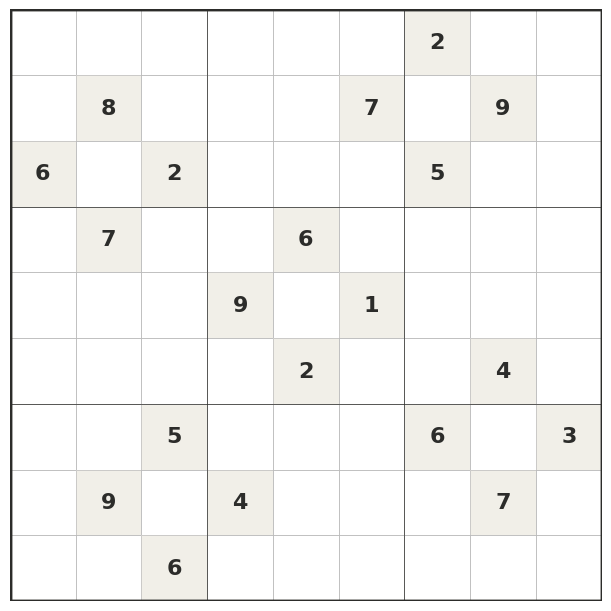

In [64]:
### Grid size
N = range(1, 10) #Numbers 1-9 for rows and columns

### Create Grid with list comprehension
Grid = pd.DataFrame([(i, j) for i in N for j in N], columns=['i', 'j'])

### Known cell values
data = [(1, 7, 2), (2, 2, 8), (2, 6, 7), (2, 8, 9),
  (3, 1, 6), (3, 3, 2), (3, 7, 5), (4, 2, 7),
  (4, 5, 6), (5, 4, 9), (5, 6, 1), (6, 5, 2), 
  (6, 8, 4), (7, 3, 5), (7, 7, 6), (7, 9, 3),
  (8, 2, 9), (8, 4, 4), (8, 8, 7), (9, 3, 6)]

data = pd.DataFrame(data, columns = ['i', 'j', 'k'])

###Final grid with known values
finalGrid = pd.merge(Grid, data, how='left').fillna(0)


#Generate the sudoku image
from sudoku_board import plot_sudoku
plot_sudoku(data)

## Model

In [65]:
#Creating the model
model = pyo.ConcreteModel(name="Sudoku")

## Sets

In [66]:
model.S_Columns = pyo.Set(initialize = range(0, 9))
model.S_Rows = pyo.Set(initialize = range(0, 9))
model.S_Numbers = pyo.Set(initialize = range(1, 10))
model.S_Blocks = pyo.Set(initialize = range(0, 3))

## Variables

Intuitively, the first idea would be to create variables such as $x_{ij}$, where $1 \le x_{ij} \le 9$. This is based on the fact that the sum of all values in each row, column, or block must equal 45 ($1+2+3+4+5+6+7+8+9 = 45$). However, it is important to consider that defining variables this way could lead to invalid solutions where the sum constraint is satisfied by incorrect combinations (for instance, a row of nine 5s also sums to 45).

To circumvent this problem, we will use binary variables $x_{ijk}$, where $x_{ijk} \in \{0, 1\}$. Each binary variable indicates whether a specific number exists in a specific cell:

* If $x_{i,j,k} = 1$, the number $k$ is present in row $i$ and column $j$.
* If $x_{i,j,k} = 0$, the number $k$ is not present in row $i$ and column $j$.

For example, if $x_{3,5,2} = 1$, it means the number **2** is placed in the **third row** and **fifth column**. Conversely, if $x_{3,2,5} = 0$, we know that the value **5** is not assigned to row 3, column 2.


In [67]:
#Create variables
model.V_numbers = pyo.Var(model.S_Rows, model.S_Columns, model.S_Numbers, domain=pyo.Binary, doc='Binary variable indicating if number k is in cell (i, j)')

## Constraints Formulation


**Row constraint -** No number repetition in each row \
$ \displaystyle \sum_{i=1}^{9} x_{ijk} = 1 \quad \text{for } j,k \in \{1, \dots, 9\}$


**Column constraint -** No number repetition in each column \
$  \displaystyle \sum_{j=1}^{9} x_{ijk} = 1 \quad \text{for } i,k \in \{1, \dots, 9\}$


**Block constraint -** No number repetition in each block \
$ \displaystyle \sum_{i=3p}^{3p + 3} \sum_{j=3q}^{3q + 3} x_{ijk} = 1 \quad \text{for } k \in \{1, \dots, 9\} \text{ and } p, q \in \{1, 2, 3\}$


This constraint is slightly more complex to interpret. It ensures that each $3 \times 3$ subgrid contains every number from 1 to 9 exactly once.

How it works:

In this formulation, **$p$** and **$q$** represent the coordinates of the $3 \times 3$ blocks rather than individual cells:
* **$p$ (Block Row):** Defines which vertical set of blocks we are in (Top, Middle, or Bottom).
* **$q$ (Block Column):** Defines which horizontal set of blocks we are in (Left, Center, or Right).

For example, if we set **$p = 1$** and **$q = 2$**, we are targeting the block located in the **first block-row** and **second block-column** (the top-middle square). 


**Non-empty constraint -** Any cell (without assignment) should NOT be empty  \
$  \displaystyle \sum_{k=1}^{9} x_{ijk} = 1 \quad \text{for } i, j \in \{1, \dots, 9\}$


**Known-cells Value -** The already provided cells should not be altered \
$ \displaystyle x_{ijk} = 1 \quad \forall (i, j, k) \in C $

$C$ being the set of pre-filled numbers

In [68]:
### Row Constraint
def RowConstraint(model, i, k):
    return sum(model.V_numbers[i, j, k] for j in model.S_Columns) == 1

### Column Constraint
def ColumnConstraint(model, j, k):
    return sum(model.V_numbers[i, j, k] for i in model.S_Rows) == 1


### Block Constraint
def block_rule(model, p, q, k):
    # i varia de 3p até 3p + 3 (inclusive)
    # j varia de 3q até 3q + 3 (inclusive)
    return sum(model.V_numbers[i, j, k] 
               for i in range(3*p, 3*p + 3)
               for j in range(3*q, 3*q + 3)) == 1

### Non-empty cells constraint
def NonEmptyCells(model, i, j):
    return sum(model.V_numbers[i, j, k] for k in model.S_Numbers) == 1

### Known-cells constraint
#We need to use a diferent approach to set the known cells, since we can't use an equality constraint for them. We will add them as constraints directly to the model.
model.C_knownCells = pyo.ConstraintList()

for _, row in finalGrid[finalGrid['k'] != 0].iterrows():
    i = int(row['i']) - 1
    j = int(row['j']) - 1
    k = int(row['k'])
    model.C_knownCells.add(model.V_numbers[i, j, k] == 1)


model.RowConstraint = pyo.Constraint(model.S_Rows, model.S_Numbers, rule=RowConstraint)
model.ColumnConstraint = pyo.Constraint(model.S_Columns, model.S_Numbers, rule=ColumnConstraint)
model.BlockConstraint = pyo.Constraint(model.S_Blocks, model.S_Blocks, model.S_Numbers, rule=block_rule)
model.NonEmptyCells = pyo.Constraint(model.S_Rows, model.S_Columns, rule=NonEmptyCells)

## Objective Function

To solve a Sudoku puzzle, finding a maximum or a minimum value does not make sense. We only need to find a **feasible solution**—one that satisfies all the defined constraints. For this reason, we will use the objective function equals 1.

$$Objective = 1$$

In [69]:
def ObjectiveFunction(model):
    return 1

#Add the objective function to the model
model.FO = pyo.Objective(rule=ObjectiveFunction, sense=pyo.minimize, doc='Minimizar o custo dos total da viagem')

## Solver


In [70]:
solver_name = 'glpk'
solver = pyo.SolverFactory(solver_name) #Since the problem is a feasibility problem, we can use any solver. GLPK is a good choice since it's open-source and can handle binary variables.

t0     = time.perf_counter()
results = solver.solve(model, tee=False)
elapsed = time.perf_counter() - t0

status = results.solver.termination_condition
print(f"  Solver : {solver_name.upper()}")
print(f"  Status : {status}")
print(f"  Time  : {elapsed:.4f} s")


  Solver : GLPK
  Status : optimal
  Time  : 0.5728 s


In [71]:
#Trasform the solution into a dataframe to visualize it better

solved_sudoku = []

for i in model.S_Rows:
    for j in model.S_Columns:
        for k in model.S_Numbers:
            if round(pyo.value(model.V_numbers[i, j, k])) == 1:
                solved_sudoku.append((i + 1, j + 1, k))  # base-0 → base-1

solution = pd.DataFrame(solved_sudoku, columns=['i', 'j', 'k'])

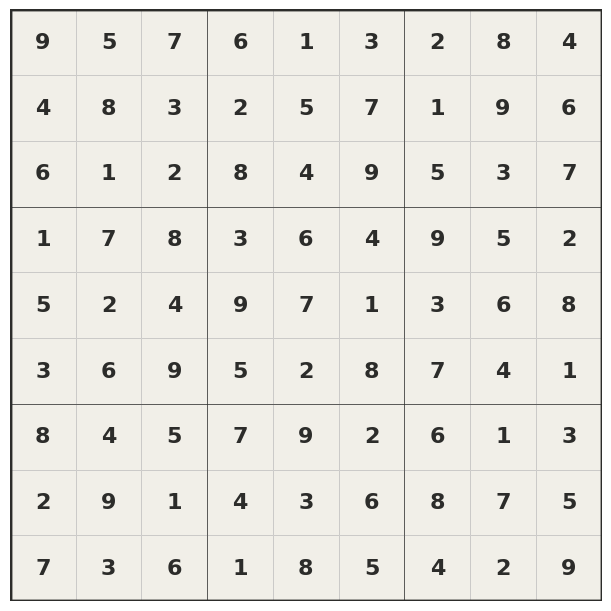

In [72]:
plot_sudoku(solution)

## References

1. [Pyomo — Optimization Modeling in Python](https://pyomo.readthedocs.io)
2. [Sudoku Solver: Linear Programming Approach Using PuLP](https://towardsdatascience.com/sudoku-solver-linear-programming-approach-using-pulp-c520cec2f8e8/)
3. [Creating Sudoku Solver with Python and Pyomo in Easy Steps](https://medium.com/@dhanalakotamohan314/creating-sudoku-solver-with-python-and-pyomo-in-easy-steps-fe22ec916090)
4. [A Sudoku Problem formulated as an LP](https://www.coin-or.org/PuLP/CaseStudies/a_sudoku_problem.html)
5. [Sudoku via Optimization](https://vanderbei.princeton.edu/tex/talks/INFORMS_19/Sudoku.pdf)


